# Sprint 1d — Comparação de Versões do Clustering

**Objetivo:** Comparar sistematicamente os resultados de clustering entre as três versões
do pipeline de pré-processamento, avaliando o impacto das melhorias incrementais na
qualidade da identificação de regimes operacionais.

## Versões comparadas
| Versão | Scaler | Features | Preprocessing | DBSCAN |
|--------|--------|----------|---------------|--------|
| **v1** | StandardScaler | 26 (todas) | Nenhum | Sweep eps × min_samples |
| **v2** | RobustScaler | ~16 (curadas) | Hampel + QuasiConst + Colinearidade | Sweep eps × min_samples |
| **v3** | RobustScaler | ~20 (curadas + eng.) | Filtro estável + FE + Hampel + Colinearidade | Sweep eps × min_samples |

## Análises
1. **Comparação entre versões** — Melhor modelo de cada versão (métricas, regimes)
2. **Comparação entre técnicas** — KMeans vs GMM vs DBSCAN em cada versão
3. **Evolução do comportamento** — Como cada técnica responde às mudanças de tratamento

**Entrada:** Tabelas PostgreSQL `s1c_v1_metricas_clustering`, `s1c_v2_metricas_clustering`, `s1c_metricas_clustering` (v3)
e CSVs locais como fallback.

**Saída:** Figuras comparativas em `figures/01_sprint1/` com prefixo `S1d_`

In [ ]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR  = PROJECT_ROOT / "figures" / "01_sprint1"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 19,
    "figure.titlesize": 21,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
# Acesso ao banco de dados
SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))
from db_utils import salvar_imagem

STAGE = "s1d"
REGIME_NAMES = {0: "Carga Reduzida", 1: "Moderado", 2: "Alta Carga"}
VERSAO_COLORS = {"v1": "#95a5a6", "v2": "#3498db", "v3": "#2ecc71"}
ALGO_MARKERS = {"KMeans": "o", "GMM": "s", "DBSCAN": "D"}

print("=" * 60)
print("  S1d — COMPARAÇÃO DE VERSÕES DO CLUSTERING")
print("=" * 60)

## 1. Carga dos Resultados

**Objetivo:** Carregar as métricas de clustering e a caracterização dos regimes das três versões,
priorizando o PostgreSQL e utilizando CSVs locais como fallback.

In [2]:
from db_utils import carregar_dataframe

cols_metricas = ["algoritmo", "n_clusters", "silhouette", "davies_bouldin",
                 "calinski_harabasz", "inertia", "bic", "selecionado"]

# ── Carregar métricas de cada versão ──
metricas = {}
regimes = {}

for versao, tabela_met, tabela_reg, csv_met, csv_reg in [
    ("v1", "s1c_v1_metricas_clustering", "s1c_v1_regimes",
     "metricas_clustering_v1.csv", "regimes_v1.csv"),
    ("v2", "s1c_v2_metricas_clustering", "s1c_v2_regimes",
     "metricas_clustering_v2.csv", "regimes_v2.csv"),
    ("v3", "s1c_v3_metricas_clustering", "s1c_v3_regimes",
     "metricas_clustering_v3.csv", "regimes_v3.csv"),
]:
    # Métricas
    try:
        df_m = carregar_dataframe(tabela_met)
        if len(df_m) == 0:
            raise ValueError("Tabela vazia")
        print(f"  {versao} métricas: banco ({len(df_m)} linhas)")
    except Exception:
        try:
            df_m = pd.read_csv(DATA_PROC / csv_met)
            print(f"  {versao} métricas: CSV local ({len(df_m)} linhas)")
        except Exception as e:
            print(f"  {versao} métricas: NÃO ENCONTRADO — {e}")
            df_m = pd.DataFrame()
    metricas[versao] = df_m
    
    # Regimes
    try:
        df_r = carregar_dataframe(tabela_reg)
        if len(df_r) == 0:
            raise ValueError("Tabela vazia")
    except Exception:
        try:
            df_r = pd.read_csv(DATA_PROC / csv_reg)
        except Exception:
            df_r = pd.DataFrame()
    regimes[versao] = df_r

# Verificar disponibilidade
versoes_ok = [v for v in ["v1", "v2", "v3"] if len(metricas[v]) > 0]
print(f"\nVersões disponíveis: {versoes_ok}")

if len(versoes_ok) < 3:
    print("\n⚠ Execute os notebooks v1, v2 e v3 antes para gerar todos os dados.")

[db_utils] 15 linhas carregadas de otimizar_moagem_aura.s1c_v1_metricas_clustering
  v1 métricas: banco (15 linhas)
[db_utils] 2 linhas carregadas de otimizar_moagem_aura.s1c_v1_regimes
[db_utils] 15 linhas carregadas de otimizar_moagem_aura.s1c_v2_metricas_clustering
  v2 métricas: banco (15 linhas)
[db_utils] 3 linhas carregadas de otimizar_moagem_aura.s1c_v2_regimes
[db_utils] 15 linhas carregadas de otimizar_moagem_aura.s1c_v3_metricas_clustering
  v3 métricas: banco (15 linhas)
[db_utils] 3 linhas carregadas de otimizar_moagem_aura.s1c_v3_regimes

Versões disponíveis: ['v1', 'v2', 'v3']


## 2. Comparação entre Versões — Melhor Modelo

**Objetivo:** Comparar o melhor modelo selecionado em cada versão, avaliando como as melhorias
incrementais no pré-processamento impactaram a qualidade do clustering (Silhouette, Davies-Bouldin,
Calinski-Harabasz).


  MELHOR MODELO POR VERSÃO
versao algoritmo  n_clusters  silhouette  davies_bouldin  calinski_harabasz
    v1    KMeans           2      0.1608          2.1965           122690.9
    v2    KMeans           3      0.1763          1.8781           109090.7
    v3    KMeans           3      0.1679          1.8152           118907.7
[db_utils] Imagem 'comparacao_versoes_melhor' salva para etapa s1d


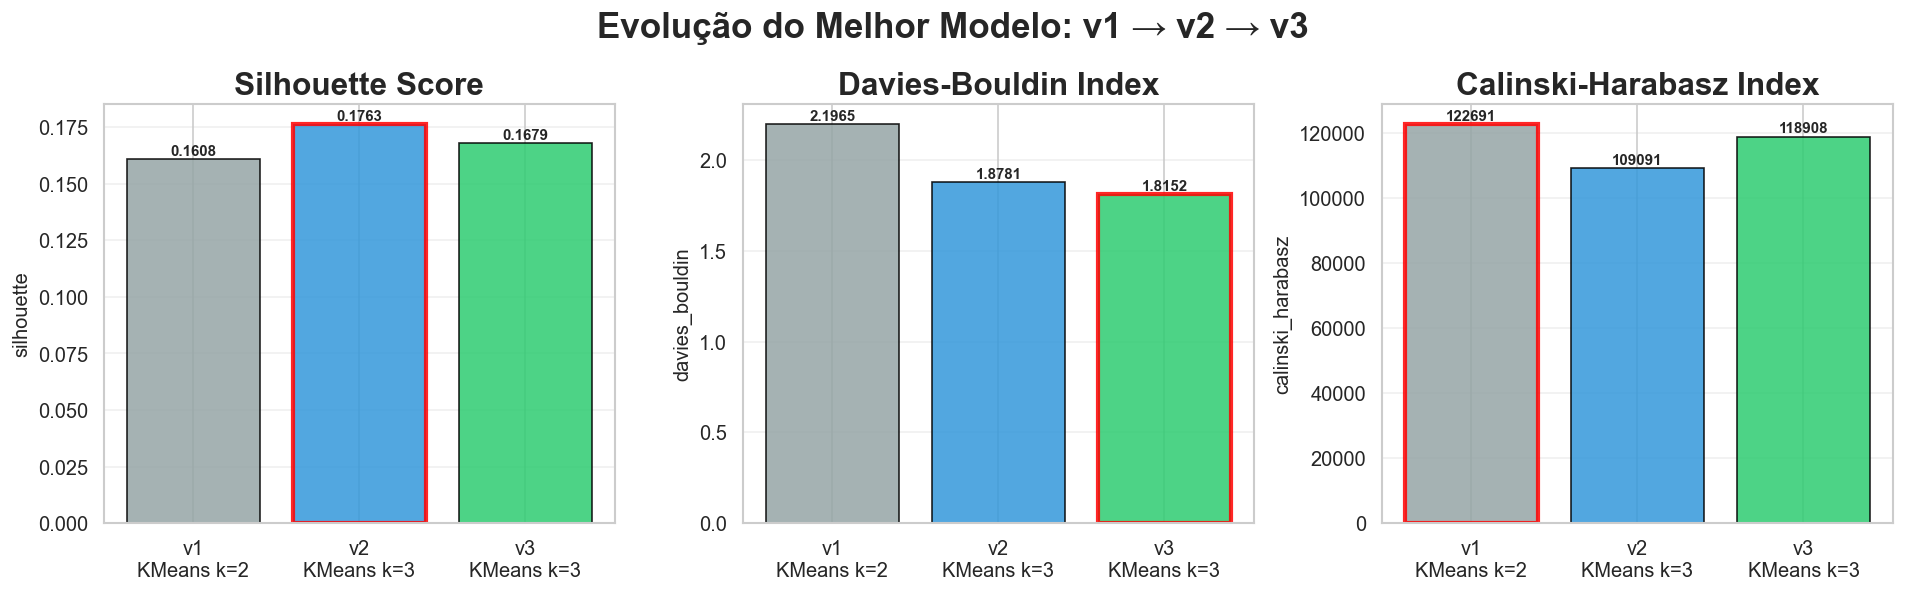

In [3]:
# ── Extrair melhor modelo de cada versão ──
rows_best = []
for v in versoes_ok:
    df_m = metricas[v]
    # Filtrar modelos selecionados ou pegar o de maior silhouette
    sel = df_m[df_m["selecionado"] == True]
    if len(sel) == 0:
        # Fallback: maior silhouette entre os válidos
        valid = df_m[df_m["silhouette"].notna()]
        if len(valid) > 0:
            sel = valid.loc[[valid["silhouette"].idxmax()]]
        else:
            continue
    best = sel.iloc[0]
    rows_best.append({
        "versao": v,
        "algoritmo": best["algoritmo"],
        "n_clusters": int(best["n_clusters"]),
        "silhouette": best["silhouette"],
        "davies_bouldin": best["davies_bouldin"],
        "calinski_harabasz": best["calinski_harabasz"],
    })

df_best = pd.DataFrame(rows_best)
print("\n" + "=" * 80)
print("  MELHOR MODELO POR VERSÃO")
print("=" * 80)
print(df_best.to_string(index=False))

# ── Gráfico comparativo: barras lado a lado ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

versoes = df_best["versao"].tolist()
colors = [VERSAO_COLORS[v] for v in versoes]
labels_bar = [f"{r['versao']}\n{r['algoritmo']} k={r['n_clusters']}" for _, r in df_best.iterrows()]

for ax, metrica, titulo, melhor in [
    (axes[0], "silhouette", "Silhouette Score", "max"),
    (axes[1], "davies_bouldin", "Davies-Bouldin Index", "min"),
    (axes[2], "calinski_harabasz", "Calinski-Harabasz Index", "max"),
]:
    vals = df_best[metrica].fillna(0).values
    bars = ax.bar(labels_bar, vals, color=colors, edgecolor="black", alpha=0.85)
    for bar, val in zip(bars, vals):
        fmt = f"{val:.4f}" if metrica != "calinski_harabasz" else f"{val:.0f}" if pd.notna(val) and val != 0 else "N/A"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt, ha="center", fontsize=9, fontweight="bold")
    ax.set_title(titulo, fontweight="bold")
    ax.set_ylabel(metrica)
    ax.grid(True, alpha=0.3, axis="y")
    # Destacar melhor
    idx_best = np.argmax(vals) if melhor == "max" else np.argmin(vals)
    bars[idx_best].set_edgecolor("red")
    bars[idx_best].set_linewidth(2.5)

fig.suptitle("Evolução do Melhor Modelo: v1 → v2 → v3", fontsize=21, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1d_01_comparacao_versoes_melhor.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "comparacao_versoes_melhor", fig, "S1d_01_comparacao_versoes_melhor.png")
plt.show()

## 3. Comparação de Regimes entre Versões

**Objetivo:** Visualizar como a distribuição e caracterização dos regimes operacionais
mudou entre as versões, evidenciando o impacto do pré-processamento na separação dos clusters.

[db_utils] Imagem 'comparacao_regimes' salva para etapa s1d


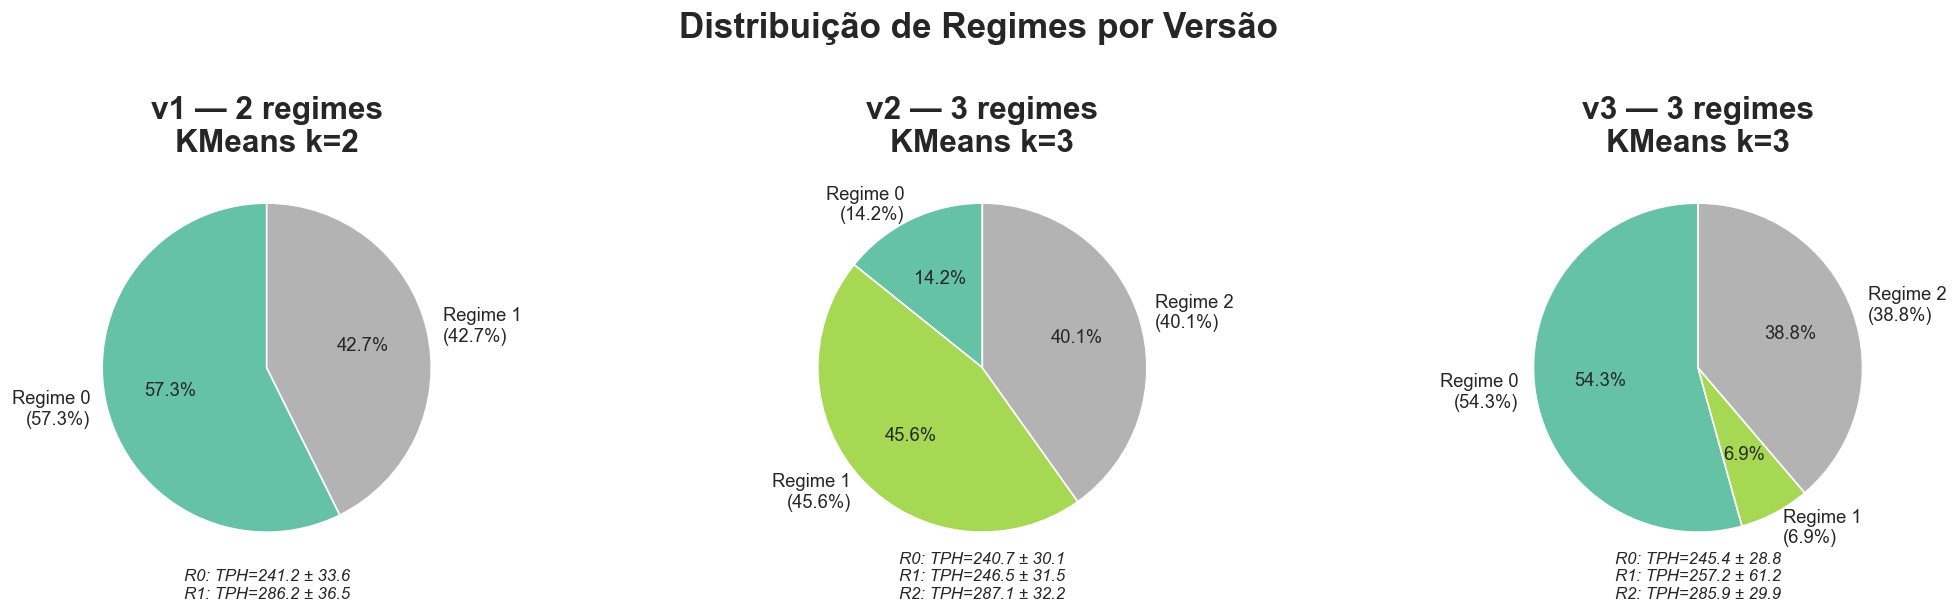

In [4]:
# ── Distribuição de regimes por versão ──
n_versoes = len(versoes_ok)
fig, axes = plt.subplots(1, n_versoes, figsize=(6 * n_versoes, 5))
if n_versoes == 1:
    axes = [axes]

for ax, v in zip(axes, versoes_ok):
    df_r = regimes[v]
    if len(df_r) == 0:
        ax.text(0.5, 0.5, f"{v}\nSem dados", ha="center", va="center", fontsize=16)
        continue
    
    labels_pie = [f"Regime {int(r['regime'])}\n({r['percentual']:.1f}%)" for _, r in df_r.iterrows()]
    sizes = df_r["percentual"].values
    colors_pie = plt.cm.Set2(np.linspace(0, 1, len(df_r)))
    
    ax.pie(sizes, labels=labels_pie, colors=colors_pie, autopct="%.1f%%",
           startangle=90, textprops={"fontsize": 11})
    
    # Info de TPH
    tph_info = "\n".join([f"R{int(r['regime'])}: TPH={r['tph_medio']:.1f} ± {r['tph_std']:.1f}"
                          for _, r in df_r.iterrows()])
    ax.text(0, -1.4, tph_info, ha="center", fontsize=10, style="italic")
    
    # Título com info do melhor modelo
    _best_match = df_best[df_best["versao"] == v]
    best_v = _best_match.iloc[0] if len(_best_match) > 0 else None
    titulo = f"{v} — {len(df_r)} regimes"
    if best_v is not None:
        titulo += f"\n{best_v['algoritmo']} k={best_v['n_clusters']}"
    ax.set_title(titulo, fontweight="bold")

fig.suptitle("Distribuição de Regimes por Versão", fontsize=21, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1d_02_comparacao_regimes.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "comparacao_regimes", fig, "S1d_02_comparacao_regimes.png")
plt.show()

## 4. Comparação entre Técnicas por Versão

**Objetivo:** Analisar como cada técnica de clustering (KMeans, GMM, DBSCAN) se comportou
em cada versão do pipeline. O foco é observar se a mudança no tratamento dos dados
beneficiou igualmente todos os algoritmos ou se algum foi mais sensível às melhorias.

**Análise:** Para KMeans e GMM, compara-se o melhor k (maior Silhouette) de cada versão.
Para DBSCAN, compara-se o resultado do sweep otimizado.

In [5]:
# ── Melhor resultado de cada técnica em cada versão ──
rows_tecnicas = []
for v in versoes_ok:
    df_m = metricas[v]
    for algo in ["KMeans", "GMM", "DBSCAN"]:
        sub = df_m[df_m["algoritmo"] == algo]
        if len(sub) == 0:
            continue
        valid = sub[sub["silhouette"].notna()]
        if len(valid) == 0:
            rows_tecnicas.append({
                "versao": v, "algoritmo": algo,
                "n_clusters": None, "silhouette": None,
                "davies_bouldin": None, "calinski_harabasz": None,
            })
            continue
        best = valid.loc[valid["silhouette"].idxmax()]
        rows_tecnicas.append({
            "versao": v,
            "algoritmo": algo,
            "n_clusters": int(best["n_clusters"]),
            "silhouette": best["silhouette"],
            "davies_bouldin": best["davies_bouldin"],
            "calinski_harabasz": best["calinski_harabasz"],
        })

df_tecnicas = pd.DataFrame(rows_tecnicas)

print("\n" + "=" * 90)
print("  MELHOR RESULTADO POR TÉCNICA × VERSÃO")
print("=" * 90)
pivot = df_tecnicas.pivot_table(
    index="algoritmo", columns="versao",
    values=["silhouette", "n_clusters"], aggfunc="first"
)
print(pivot.round(4).to_string())


  MELHOR RESULTADO POR TÉCNICA × VERSÃO
          n_clusters           silhouette                
versao            v1   v2   v3         v1      v2      v3
algoritmo                                                
GMM              2.0  4.0  2.0     0.1580  0.1506  0.1152
KMeans           2.0  3.0  3.0     0.1608  0.1763  0.1679


[db_utils] Imagem 'tecnicas_por_versao' salva para etapa s1d


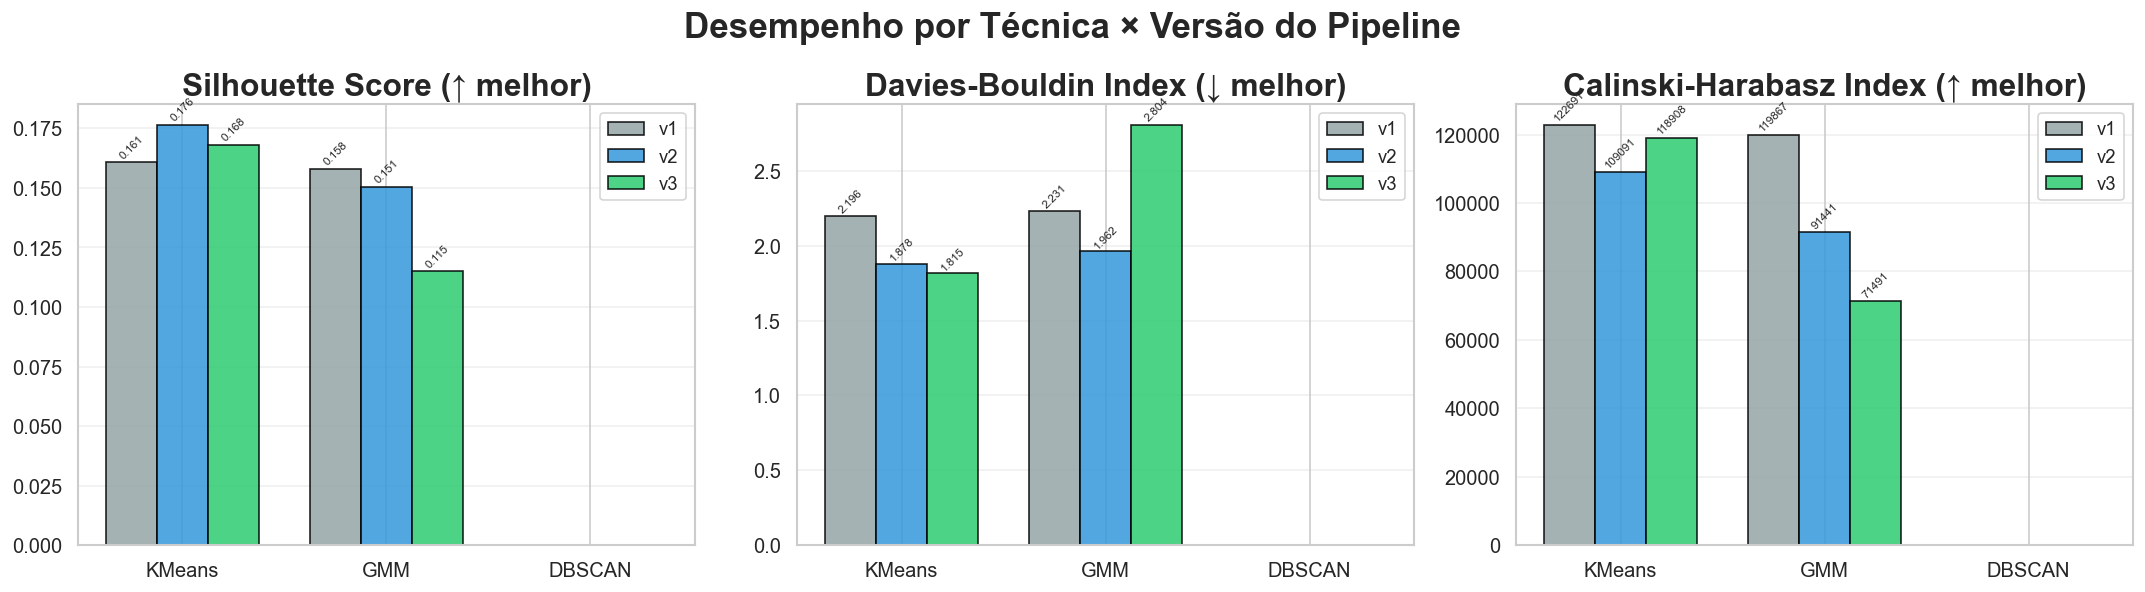

In [6]:
# ── Gráfico: Silhouette por técnica × versão ──
algos = ["KMeans", "GMM", "DBSCAN"]
x = np.arange(len(algos))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metrica, titulo, melhor in [
    (axes[0], "silhouette", "Silhouette Score (↑ melhor)", "max"),
    (axes[1], "davies_bouldin", "Davies-Bouldin Index (↓ melhor)", "min"),
    (axes[2], "calinski_harabasz", "Calinski-Harabasz Index (↑ melhor)", "max"),
]:
    for i, v in enumerate(versoes_ok):
        vals = []
        for algo in algos:
            row = df_tecnicas[(df_tecnicas["versao"] == v) & (df_tecnicas["algoritmo"] == algo)]
            if len(row) > 0 and pd.notna(row.iloc[0][metrica]):
                vals.append(row.iloc[0][metrica])
            else:
                vals.append(0)
        bars = ax.bar(x + i * width, vals, width, label=v,
                      color=VERSAO_COLORS[v], edgecolor="black", alpha=0.85)
        for bar, val in zip(bars, vals):
            if val > 0:
                fmt = f"{val:.3f}" if metrica != "calinski_harabasz" else f"{val:.0f}"
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                        fmt, ha="center", fontsize=7, rotation=45)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(algos)
    ax.set_title(titulo, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Desempenho por Técnica × Versão do Pipeline", fontsize=21, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1d_03_tecnicas_por_versao.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "tecnicas_por_versao", fig, "S1d_03_tecnicas_por_versao.png")
plt.show()

## 5. Evolução do Comportamento por Técnica

**Objetivo:** Visualizar a trajetória de cada técnica ao longo das versões.
Linhas que sobem indicam que o tratamento de dados beneficiou aquele algoritmo;
linhas que descem indicam que a mudança prejudicou ou que o algoritmo é menos
sensível ao pré-processamento.

Inclui também a curva de Silhouette por k para KMeans e GMM, mostrando como
o perfil completo de avaliação muda entre versões.

[db_utils] Imagem 'evolucao_tecnicas' salva para etapa s1d


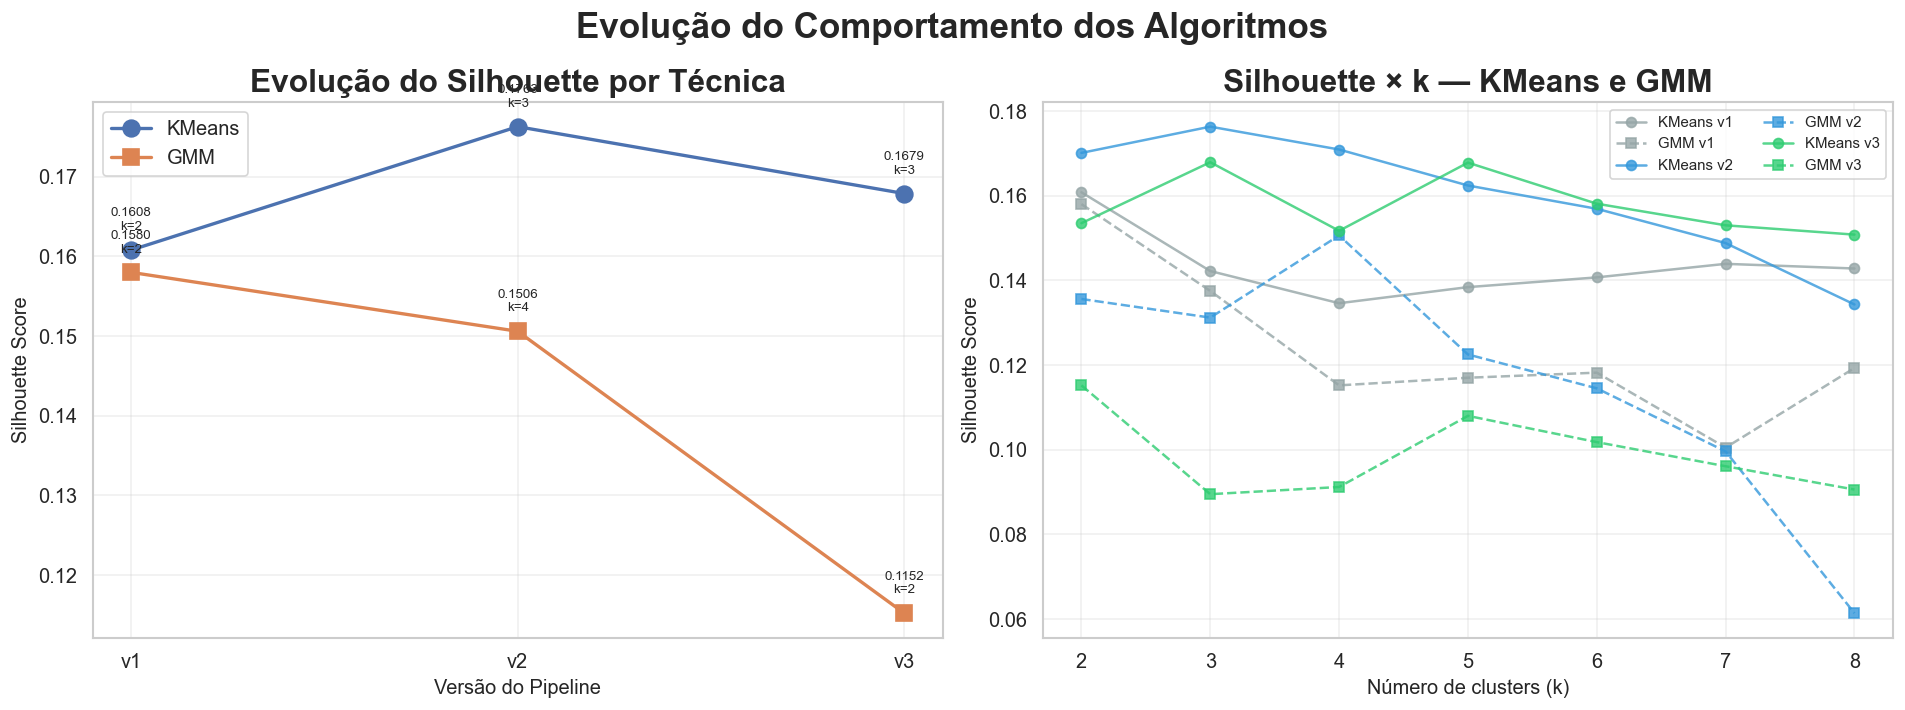

In [7]:
# ── Linha de evolução: Silhouette do melhor k por técnica ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 5a. Evolução do Silhouette por técnica
ax = axes[0]
for algo in algos:
    sub = df_tecnicas[df_tecnicas["algoritmo"] == algo]
    sub_valid = sub[sub["silhouette"].notna()]
    if len(sub_valid) > 0:
        ax.plot(sub_valid["versao"], sub_valid["silhouette"],
                marker=ALGO_MARKERS[algo], label=algo, linewidth=2, markersize=10)
        for _, row in sub_valid.iterrows():
            k_info = f"k={int(row['n_clusters'])}" if pd.notna(row['n_clusters']) else ""
            ax.annotate(f"{row['silhouette']:.4f}\n{k_info}",
                       (row["versao"], row["silhouette"]),
                       textcoords="offset points", xytext=(0, 12),
                       ha="center", fontsize=8)

ax.set_xlabel("Versão do Pipeline")
ax.set_ylabel("Silhouette Score")
ax.set_title("Evolução do Silhouette por Técnica", fontweight="bold")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# 5b. Curvas Silhouette × k para KMeans (todas as versões)
ax = axes[1]
for v in versoes_ok:
    df_m = metricas[v]
    for algo, ls in [("KMeans", "-"), ("GMM", "--")]:
        sub = df_m[(df_m["algoritmo"] == algo) & (df_m["silhouette"].notna())]
        if len(sub) > 0:
            sub = sub.sort_values("n_clusters")
            ax.plot(sub["n_clusters"], sub["silhouette"],
                    marker=ALGO_MARKERS[algo], ls=ls,
                    color=VERSAO_COLORS[v], label=f"{algo} {v}",
                    linewidth=1.5, markersize=6, alpha=0.8)

ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette × k — KMeans e GMM", fontweight="bold")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

fig.suptitle("Evolução do Comportamento dos Algoritmos", fontsize=21, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1d_04_evolucao_tecnicas.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "evolucao_tecnicas", fig, "S1d_04_evolucao_tecnicas.png")
plt.show()

## 6. Tabela Resumo Consolidada

**Objetivo:** Apresentar uma tabela completa com todas as métricas, facilitando
a referência no relatório do projeto.


  TABELA RESUMO — COMPARAÇÃO DE VERSÕES
Versão                                           Preprocessing Algoritmo  k Silhouette Davies-Bouldin Calinski-Harabasz
    v1                     StandardScaler, 26 vars, sem filtro    KMeans  2     0.1608         2.1965            122691
    v2            RobustScaler, ~16 vars, Hampel+Colinearidade    KMeans  3     0.1763         1.8781            109091
    v3 RobustScaler, ~20 vars, Filtro estável+FE+Colinearidade    KMeans  3     0.1679         1.8152            118908

  TABELA POR TÉCNICA × VERSÃO

  KMeans:
    v1: Sil=0.1608  DB=2.1965  k=2
    v2: Sil=0.1763  DB=1.8781  k=3
    v3: Sil=0.1679  DB=1.8152  k=3

  GMM:
    v1: Sil=0.1580  DB=2.2305  k=2
    v2: Sil=0.1506  DB=1.9616  k=4
    v3: Sil=0.1152  DB=2.8040  k=2

  DBSCAN:
    v1: Sil=N/A  DB=N/A  N/A
    v2: Sil=N/A  DB=N/A  N/A
    v3: Sil=N/A  DB=N/A  N/A
[db_utils] Imagem 'tabela_resumo' salva para etapa s1d


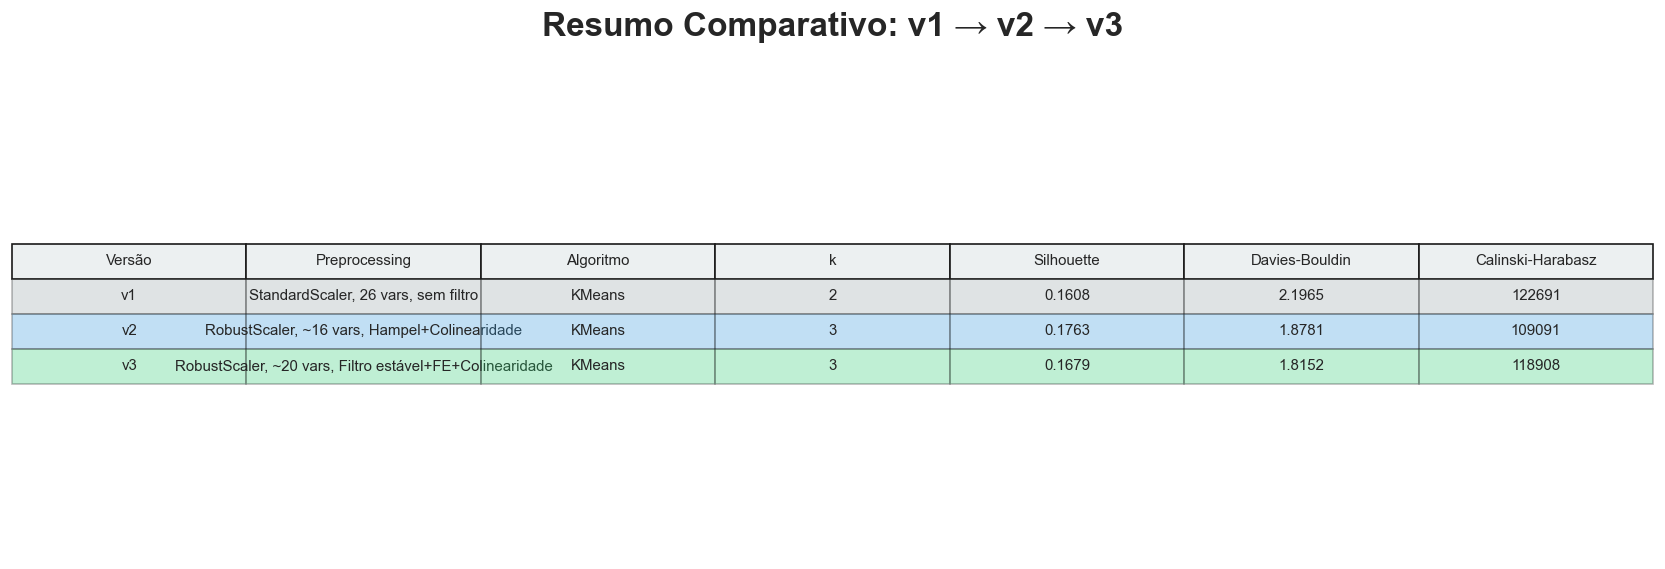


CSVs salvos em C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed


In [8]:
# ── Tabela resumo: melhor por versão ──
preprocessing_desc = {
    "v1": "StandardScaler, 26 vars, sem filtro",
    "v2": "RobustScaler, ~16 vars, Hampel+Colinearidade",
    "v3": "RobustScaler, ~20 vars, Filtro estável+FE+Colinearidade",
}

rows_resumo = []
for _, r in df_best.iterrows():
    v = r["versao"]
    df_r = regimes[v]
    n_regimes = len(df_r) if len(df_r) > 0 else r["n_clusters"]
    rows_resumo.append({
        "Versão": v,
        "Preprocessing": preprocessing_desc.get(v, ""),
        "Algoritmo": r["algoritmo"],
        "k": r["n_clusters"],
        "Silhouette": f"{r['silhouette']:.4f}" if pd.notna(r["silhouette"]) else "N/A",
        "Davies-Bouldin": f"{r['davies_bouldin']:.4f}" if pd.notna(r["davies_bouldin"]) else "N/A",
        "Calinski-Harabasz": f"{r['calinski_harabasz']:.0f}" if pd.notna(r["calinski_harabasz"]) else "N/A",
    })

df_resumo = pd.DataFrame(rows_resumo)
print("\n" + "=" * 100)
print("  TABELA RESUMO — COMPARAÇÃO DE VERSÕES")
print("=" * 100)
print(df_resumo.to_string(index=False))

# ── Tabela por técnica ──
print("\n" + "=" * 100)
print("  TABELA POR TÉCNICA × VERSÃO")
print("=" * 100)
for algo in algos:
    print(f"\n  {algo}:")
    sub = df_tecnicas[df_tecnicas["algoritmo"] == algo]
    for _, r in sub.iterrows():
        sil = f"{r['silhouette']:.4f}" if pd.notna(r['silhouette']) else "N/A"
        db = f"{r['davies_bouldin']:.4f}" if pd.notna(r['davies_bouldin']) else "N/A"
        k = f"k={int(r['n_clusters'])}" if pd.notna(r['n_clusters']) else "N/A"
        print(f"    {r['versao']}: Sil={sil}  DB={db}  {k}")

# Salvar tabela como imagem
fig, ax = plt.subplots(figsize=(14, 3 + len(rows_resumo) * 0.6))
ax.axis("off")
table = ax.table(
    cellText=df_resumo.values,
    colLabels=df_resumo.columns,
    loc="center", cellLoc="center",
    colColours=["#ecf0f1"] * len(df_resumo.columns)
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# Colorir linhas por versão
for i, v in enumerate(df_resumo["Versão"]):
    color = VERSAO_COLORS.get(v, "#ffffff")
    for j in range(len(df_resumo.columns)):
        table[i + 1, j].set_facecolor(color)
        table[i + 1, j].set_alpha(0.3)

fig.suptitle("Resumo Comparativo: v1 → v2 → v3", fontsize=20, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1d_05_tabela_resumo.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "tabela_resumo", fig, "S1d_05_tabela_resumo.png")
plt.show()

# Salvar CSV
df_resumo.to_csv(DATA_PROC / "comparacao_versoes_clustering.csv", index=False)
df_tecnicas.to_csv(DATA_PROC / "comparacao_tecnicas_clustering.csv", index=False)
print(f"\nCSVs salvos em {DATA_PROC}")

## 7. Conclusões

**Objetivo:** Sintetizar as principais conclusões da análise comparativa.

In [9]:
print("\n" + "=" * 70)
print("  CONCLUSÕES — COMPARAÇÃO DE VERSÕES")
print("=" * 70)

if len(df_best) >= 2:
    # Delta entre primeira e última versão
    first = df_best.iloc[0]
    last = df_best.iloc[-1]
    delta_sil = last["silhouette"] - first["silhouette"]
    pct_sil = 100 * delta_sil / first["silhouette"] if first["silhouette"] > 0 else 0
    
    print(f"\n  1. EVOLUÇÃO GERAL:")
    print(f"     Silhouette: {first['versao']}={first['silhouette']:.4f} → {last['versao']}={last['silhouette']:.4f}")
    print(f"     Delta: {delta_sil:+.4f} ({pct_sil:+.1f}%)")
    
    print(f"\n  2. MODELO SELECIONADO:")
    for _, r in df_best.iterrows():
        print(f"     {r['versao']}: {r['algoritmo']} com k={r['n_clusters']}")
    
    print(f"\n  3. IMPACTO POR TÉCNICA:")
    for algo in algos:
        sub = df_tecnicas[(df_tecnicas["algoritmo"] == algo) & (df_tecnicas["silhouette"].notna())]
        if len(sub) >= 2:
            first_a = sub.iloc[0]
            last_a = sub.iloc[-1]
            delta = last_a["silhouette"] - first_a["silhouette"]
            print(f"     {algo}: {first_a['silhouette']:.4f} → {last_a['silhouette']:.4f} (Δ={delta:+.4f})")
        elif len(sub) == 1:
            print(f"     {algo}: {sub.iloc[0]['silhouette']:.4f} (apenas {sub.iloc[0]['versao']})")
        else:
            print(f"     {algo}: sem resultados válidos")

# Listar apenas as figuras geradas por ESTE notebook (prefixo S1d_)
figuras_s1d = sorted(FIGURES_DIR.glob("S1d_*.png"))
print(f"\n  4. FIGURAS GERADAS NESTE NOTEBOOK: {len(figuras_s1d)}")
for f in figuras_s1d:
    print(f"     {f.name}")
print("=" * 70)


  CONCLUSÕES — COMPARAÇÃO DE VERSÕES

  1. EVOLUÇÃO GERAL:
     Silhouette: v1=0.1608 → v3=0.1679
     Delta: +0.0071 (+4.4%)

  2. MODELO SELECIONADO:
     v1: KMeans com k=2
     v2: KMeans com k=3
     v3: KMeans com k=3

  3. IMPACTO POR TÉCNICA:
     KMeans: 0.1608 → 0.1679 (Δ=+0.0071)
     GMM: 0.1580 → 0.1152 (Δ=-0.0428)
     DBSCAN: sem resultados válidos

  4. FIGURAS GERADAS NESTE NOTEBOOK: 5
     S1d_01_comparacao_versoes_melhor.png
     S1d_02_comparacao_regimes.png
     S1d_03_tecnicas_por_versao.png
     S1d_04_evolucao_tecnicas.png
     S1d_05_tabela_resumo.png


In [10]:
# ==============================================================================
# Exportar notebook para HTML
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)

from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\01_sprint1\d_comparacao_versoes.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "d_comparacao_versoes.html"
_out_path.write_text(_html_body, encoding="utf-8")
print("HTML exportado:", _out_path)

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\d_comparacao_versoes.html
